# Photoacoustic Tomography: Universal Back-Projection Reconstruction

This notebook demonstrates photoacoustic tomography (PAT) reconstruction using the
universal back-projection algorithm of Xu & Wang (2005). We recover the initial
pressure distribution of spherical absorbers from acoustic time-series measured on a
planar detector array.

**Contents:**
1. Background and physics
2. Target configuration and detector layout
3. Simulated PA signals (time traces)
4. Universal back-projection reconstruction
5. Evaluation and cross-sections

All results are loaded from precomputed reference outputs so the notebook runs in seconds.

In [1]:
import os
os.chdir(os.path.join(os.path.dirname(os.path.abspath('.')), ''))
# If running from notebooks/, go up one level
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')
print('Working directory:', os.getcwd())

Working directory: /Users/jiayx/Edu/Umich/inverse-101/imaging-101/tasks/photoacoustic_tomography


In [2]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import json

from src.preprocessing import load_raw_data, load_ground_truth, load_metadata
from src.visualization import (
    compute_ncc, compute_nrmse, centre_crop,
    plot_reconstruction, plot_cross_sections, plot_signals,
)

## 1. Background

**Photoacoustic effect:** A short laser pulse illuminates tissue. Optical absorbers
(e.g., blood vessels) absorb the light, undergo rapid thermoelastic expansion, and
launch broadband ultrasonic pressure waves.

**Forward model for a spherical absorber** of radius $R_a$ at position $\mathbf{r}_s$,
detected at $\mathbf{r}_d$:

$$p(\mathbf{r}_d, t) = \frac{R - ct}{2R} \cdot \Theta\bigl(R_a - |R - ct|\bigr)$$

where $R = |\mathbf{r}_d - \mathbf{r}_s|$ is the source-detector distance, $c = 1484$ m/s
is the sound speed in water, and $\Theta$ is the Heaviside step function.

**Universal back-projection** recovers the initial pressure:

$$p_0(\mathbf{r}) = \frac{\sum_d \omega_d \cdot b_d(|\mathbf{r} - \mathbf{r}_d|/c)}{\sum_d \omega_d}$$

where $b(t) = 2p(t) - 2tc\,\tilde{p}(t)$, $\tilde{p} = \mathcal{F}^{-1}\{-ik \cdot \mathcal{F}\{p\}\}$
is the ramp-filtered signal, and $\omega_d$ is the solid-angle weight of each detector.

## 2. Data and Configuration

In [3]:
# Load data
signals, xd, yd, t = load_raw_data('data')
gt_image, image_x, image_y = load_ground_truth('data')
meta = load_metadata('data')

print(f"Signals shape: {signals.shape}")
print(f"Detector array: {len(xd)} x {len(yd)}")
print(f"Time samples: {len(t)}, duration: {t[-1]*1e6:.0f} us")
print(f"Sound speed: {meta['sound_speed_m_per_s']} m/s")
print(f"Target plane: z = {meta['target_plane_z_m']*1e3:.0f} mm")

Signals shape: (1301, 31, 31)
Detector array: 31 x 31
Time samples: 1301, duration: 65 us
Sound speed: 1484.0 m/s
Target plane: z = 15 mm


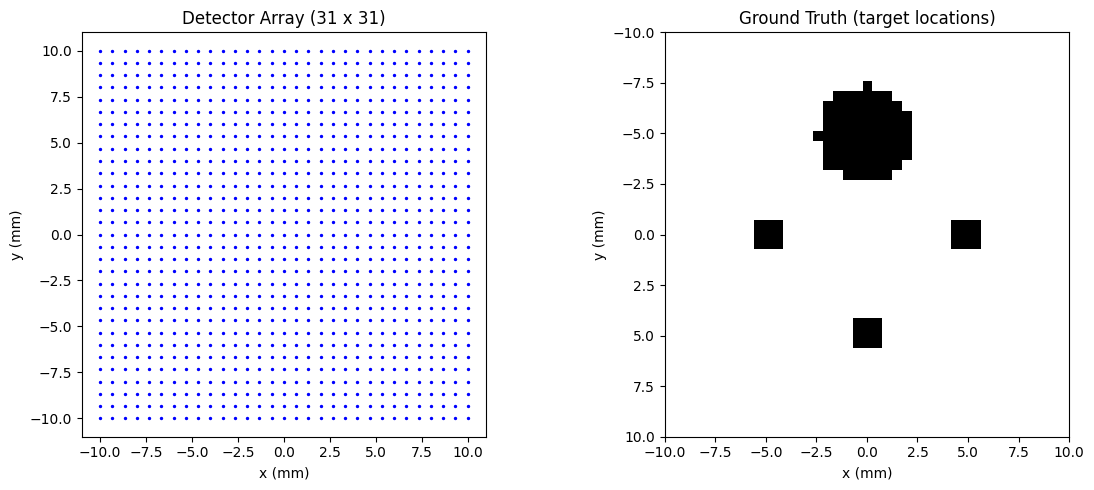

In [4]:
# Detector layout
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Detector positions
Yd, Xd = np.meshgrid(yd * 1e3, xd * 1e3)
axes[0].scatter(Xd.ravel(), Yd.ravel(), s=2, c='blue')
axes[0].set_xlabel('x (mm)')
axes[0].set_ylabel('y (mm)')
axes[0].set_title(f'Detector Array ({len(xd)} x {len(yd)})')
axes[0].set_aspect('equal')

# Ground truth
extent_gt = [image_x[0]*1e3, image_x[-1]*1e3, image_y[-1]*1e3, image_y[0]*1e3]
axes[1].imshow(gt_image.T, extent=extent_gt, cmap='gray_r')
axes[1].set_xlabel('x (mm)')
axes[1].set_ylabel('y (mm)')
axes[1].set_title('Ground Truth (target locations)')

plt.tight_layout()
plt.show()

## 3. PA Signals (Time Traces)

The forward model generates time-domain pressure traces at each detector. Each trace
shows pulses arriving from the spherical targets, with arrival time proportional to
source-detector distance.

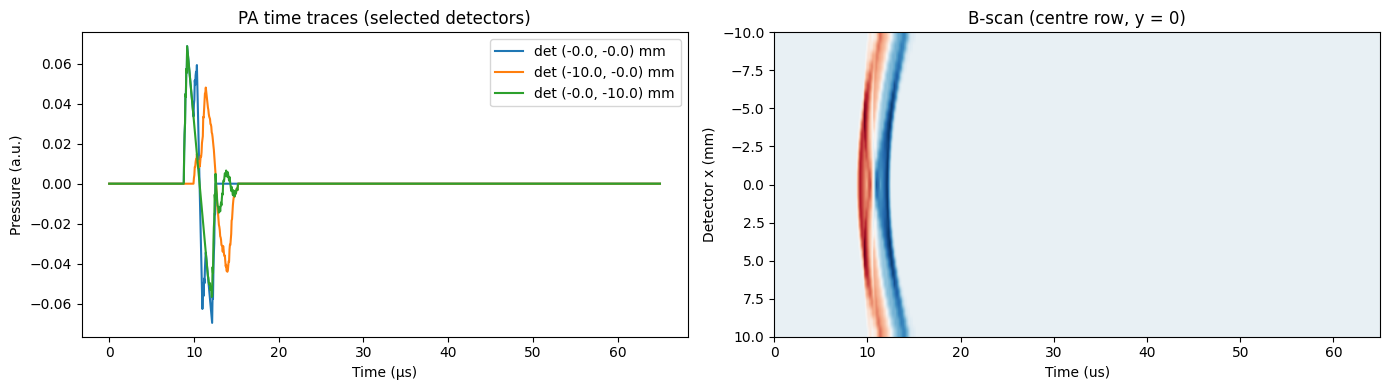

In [5]:
# Plot time traces for selected detectors
mid = len(xd) // 2

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Centre and corner detectors
plot_signals(signals, t, xd, yd,
             det_indices=[(mid, mid), (0, mid), (mid, 0)],
             ax=axes[0])
axes[0].set_title('PA time traces (selected detectors)')

# B-scan (time vs detector index for centre row)
bscan = signals[:, :, mid]
axes[1].imshow(bscan.T, aspect='auto',
               extent=[t[0]*1e6, t[-1]*1e6, xd[-1]*1e3, xd[0]*1e3],
               cmap='RdBu_r')
axes[1].set_xlabel('Time (us)')
axes[1].set_ylabel('Detector x (mm)')
axes[1].set_title('B-scan (centre row, y = 0)')

plt.tight_layout()
plt.show()

## 4. Reconstruction

We load the precomputed universal back-projection reconstruction from `evaluation/reference_outputs/`.

In [6]:
# Load precomputed reconstruction
ref = np.load('evaluation/reference_outputs/reconstruction.npz')
recon = ref['reconstruction'][0]  # remove batch dim
xf = ref['image_x'][0]
yf = ref['image_y'][0]

print(f"Reconstruction shape: {recon.shape}")
print(f"Pixel size: {(xf[1]-xf[0])*1e3:.2f} mm")
print(f"Field of view: {(xf[-1]-xf[0])*1e3:.1f} x {(yf[-1]-yf[0])*1e3:.1f} mm")

Reconstruction shape: (41, 41)
Pixel size: 0.50 mm
Field of view: 20.0 x 20.0 mm


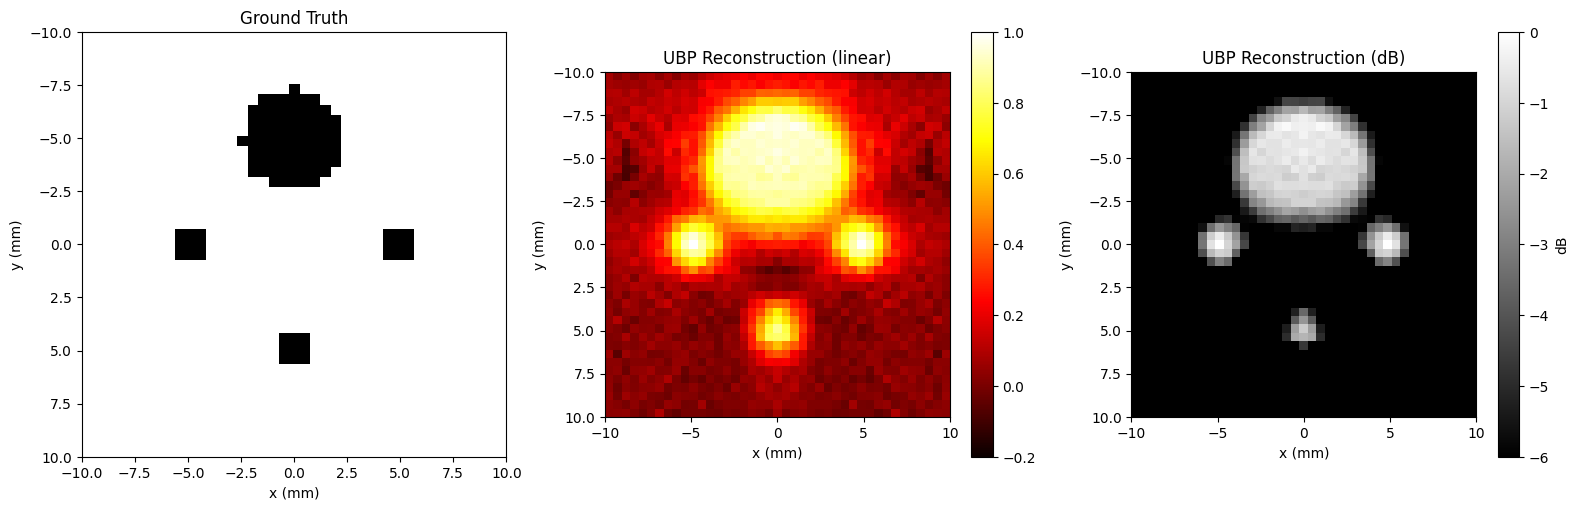

In [7]:
# Display reconstruction
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Ground truth
axes[0].imshow(gt_image.T, extent=extent_gt, cmap='gray_r')
axes[0].set_xlabel('x (mm)')
axes[0].set_ylabel('y (mm)')
axes[0].set_title('Ground Truth')

# Reconstruction (linear)
extent_r = [xf[0]*1e3, xf[-1]*1e3, yf[-1]*1e3, yf[0]*1e3]
im = axes[1].imshow(recon.T, extent=extent_r, cmap='hot', vmin=-0.2, vmax=1.0)
axes[1].set_xlabel('x (mm)')
axes[1].set_ylabel('y (mm)')
axes[1].set_title('UBP Reconstruction (linear)')
plt.colorbar(im, ax=axes[1])

# Reconstruction (dB)
plot_reconstruction(recon, xf, yf, ax=axes[2],
                    title='UBP Reconstruction (dB)', dynamic_range_db=6)

plt.tight_layout()
plt.show()

## 5. Cross-Sections and Evaluation

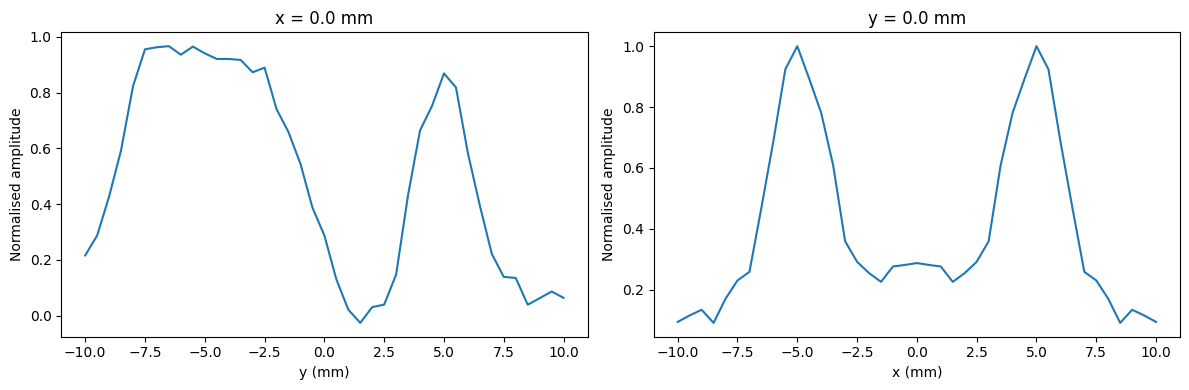

In [8]:
# Cross-sections through the reconstruction
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_cross_sections(recon, xf, yf, axes=axes)
plt.tight_layout()
plt.show()

In [9]:
# Compute metrics
recon_crop = centre_crop(recon, fraction=0.8)
gt_crop = centre_crop(gt_image, fraction=0.8)

ncc = compute_ncc(recon_crop, gt_crop)
nrmse = compute_nrmse(recon_crop, gt_crop)

print(f"NCC  (centre 80%): {ncc:.4f}")
print(f"NRMSE (centre 80%): {nrmse:.4f}")

# Load metrics boundaries
with open('evaluation/metrics.json') as f:
    metrics = json.load(f)
print(f"\nNCC boundary:   {metrics['ncc_boundary']}")
print(f"NRMSE boundary: {metrics['nrmse_boundary']}")
print(f"NCC passes:  {ncc >= metrics['ncc_boundary']}")
print(f"NRMSE passes: {nrmse <= metrics['nrmse_boundary']}")

NCC  (centre 80%): 0.6099
NRMSE (centre 80%): 0.3590

NCC boundary:   0.5489
NRMSE boundary: 0.3949
NCC passes:  True
NRMSE passes: True


## Running the Full Pipeline from Scratch

The code below runs the complete pipeline (data generation + reconstruction) instead of
loading precomputed results. Uncomment to execute (takes a few seconds).

In [10]:
# # Uncomment to run the full pipeline from scratch:
#
# from src.generate_data import define_targets, define_detector_array, define_time_vector
# from src.physics_model import simulate_pa_signals
# from src.solvers import universal_back_projection
#
# tar_info, z_target = define_targets()
# xd, yd = define_detector_array()
# t, fs = define_time_vector()
#
# # Forward simulation
# signals = simulate_pa_signals(tar_info, xd, yd, t, c=1484.0)
# print(f'Signals shape: {signals.shape}')
#
# # Reconstruction
# recon, xf, yf, zf = universal_back_projection(
#     signals, xd, yd, t, z_target, c=1484.0,
#     resolution=500e-6, det_area=(2e-3)**2)
# print(f'Reconstruction shape: {np.squeeze(recon).shape}')

## Summary

This notebook demonstrated photoacoustic tomography reconstruction:

- **Forward model**: Simulated PA signals from 4 spherical absorbers (3 small at 1.5 mm
  diameter, 1 large at 5 mm diameter) detected by a 31x31 planar array.
- **Reconstruction**: Universal back-projection with ramp filtering and solid-angle
  weighting successfully recovers the target locations.
- **Limitations**: The finite aperture (20 mm) and limited angular coverage produce
  sidelobe artefacts and imperfect localisation, reflected in the moderate NCC. The
  comparison between a binary ground truth and a continuous reconstruction further
  reduces the NCC metric, though the targets are clearly resolved in the image.